# Week 2 实验：vLLM 部署 Qwen2.5-7B 与并发压测

> 本 Notebook 完整复现「部署一个 OpenAI 兼容推理服务 + 验证 Week 1 理论预言」的全过程。
> **硬件**：RTX 5090 (32GB) · **引擎**：vLLM 0.25.1 (V1 架构) · **模型**：Qwen2.5-7B-Instruct（平台共享模型库，免下载）
>
> 学习路径：[Week 1 理论笔记](https://github.com/) 中手推的三个预言，本实验逐一验证：
> 1. 单用户 decode 速度 ≈ 118 tok/s 物理上限（带宽瓶颈）
> 2. 并发 1→64，每用户速度几乎不降（免费午餐区）
> 3. KV Cache 容量 ≈ 25 万 token（显存即吞吐）
>
> **使用方式**：从上往下逐格执行（Shift+Enter）。全程约 10 分钟。

## 0. 环境检查

先确认 GPU、vLLM、模型文件三者就位。

In [2]:
# GPU 信息
!nvidia-smi --query-gpu=name,memory.total,memory.used,driver_version --format=csv

name, memory.total [MiB], memory.used [MiB], driver_version
NVIDIA GeForce RTX 5090, 32607 MiB, 2 MiB, 610.57.04


In [4]:
# vLLM 与 PyTorch 版本（5090 是 Blackwell 新架构，需要新栈支持）
import vllm, torch
print(f"vLLM {vllm.__version__} | torch {torch.__version__} | CUDA {torch.version.cuda}")

vLLM 0.25.1 | torch 2.11.0+cu130 | CUDA 13.0


In [5]:
# 模型文件（/model 是平台共享模型库，开机自动挂载）
import os
MODEL_PATH = "/model/ModelScope/Qwen/Qwen2.5-7B-Instruct"
total = sum(os.path.getsize(os.path.join(MODEL_PATH, f))
            for f in os.listdir(MODEL_PATH) if f.endswith(".safetensors"))
print(f"模型文件：{MODEL_PATH}")
print(f"权重总大小：{total/1e9:.1f} GB（对照 Week 1 手算：7.6B 参数 × 2 字节 ≈ 15.2 GB）")

模型文件：/model/ModelScope/Qwen/Qwen2.5-7B-Instruct
权重总大小：15.2 GB（对照 Week 1 手算：7.6B 参数 × 2 字节 ≈ 15.2 GB）


## 1. 启动 vLLM 服务

### 启动参数逐条解释

| 参数 | 作用 | Week 1/2 对应概念 |
|---|---|---|
| `--max-model-len 8192` | 单请求最大上下文 8K | 直接决定 KV Cache 怎么分配 |
| `--gpu-memory-utilization 0.90` | 允许用掉 90% 显存 | 权重外的显存全部划给 KV Cache 池 |
| `--served-model-name` | API 里显示的模型名 | OpenAI 兼容接口 |

> 🐛 **踩坑记录**：本镜像首次启动会报 `FileNotFoundError: 'ninja'`——V1 引擎的 FlashInfer 需要即时编译 kernel，依赖 ninja。下面先装好再启动。

In [6]:
# 修复依赖（只需一次）
!pip install -q ninja
print("ninja 就绪")

ninja 就绪


ninja 就绪


In [7]:
import subprocess, time, urllib.request, json, signal, os, sys

# 后台启动 vLLM 服务（日志写入文件，方便之后分析）
LOG = "/workspace/vllm.log"
MODEL_PATH = "/model/ModelScope/Qwen/Qwen2.5-7B-Instruct"
VLLM_BIN = os.path.join(sys.exec_prefix, "bin", "vllm")
CMD = [
    VLLM_BIN, "serve", MODEL_PATH,
    "--served-model-name", "Qwen2.5-7B-Instruct",
    "--max-model-len", "8192",
    "--gpu-memory-utilization", "0.90",
    "--port", "8000",
]

log_f = open(LOG, "w")
server = subprocess.Popen(CMD, stdout=log_f, stderr=subprocess.STDOUT)
print(f"vLLM 服务已启动，PID={server.pid}，首次启动约 2-3 分钟（含 kernel 编译与 CUDA Graph 捕获）...")

vLLM 服务已启动，PID=1212，首次启动约 2-3 分钟（含 kernel 编译与 CUDA Graph 捕获）...


In [12]:
# 等待服务就绪（轮询 /v1/models）
for i in range(60):
    try:
        with urllib.request.urlopen("http://localhost:8000/v1/models", timeout=2) as r:
            models = json.load(r)
            print(f"✅ 服务就绪！可用模型: {[m['id'] for m in models['data']]}")
            break
    except Exception:
        time.sleep(5)
else:
    raise RuntimeError("服务启动超时，请检查 /workspace/vllm.log")

✅ 服务就绪！可用模型: ['Qwen2.5-7B-Instruct']


## 2. 读懂启动日志（Week 1 手算 vs 实机）

vLLM 启动时会做一次「假推理」量出剩余显存，算出 KV Cache 能放多少个 token。
**这是 Week 1 手算结果的第一次实机验证**——我们当时手推的是「约 25 万个 token」。

In [11]:
# 从日志中提取关键信息
import re
log = open(LOG).read()
for pattern, label in [
    (r"Model loading took ([\d.]+) GiB", "权重占显存"),
    (r"GPU KV cache size: ([\d,]+) tokens", "KV Cache 容量"),
    (r"Maximum concurrency for ([\d,]+) tokens per request: ([\d.]+)x", "满上下文并发数"),
]:
    m = re.search(pattern, log)
    if m:
        print(f"📊 {label}: {', '.join(m.groups())}")

# 对照 Week 1 手算：每 token KV = 2(K,V) × 28层 × 4KV头 × 128维 × 2字节 = 56 KB
print()
print("Week 1 手算：每 token KV Cache = 56 KB，32GB 卡上权重外约 14GB 可用")
print("→ 14GB ÷ 56KB ≈ 25 万 token，和上面的实测值对照一下？")

📊 权重占显存: 14.29
📊 KV Cache 容量: 253,056
📊 满上下文并发数: 8,192, 30.89

Week 1 手算：每 token KV Cache = 56 KB，32GB 卡上权重外约 14GB 可用
→ 14GB ÷ 56KB ≈ 25 万 token，和上面的实测值对照一下？


## 3. 第一个请求（OpenAI 兼容接口）

vLLM 提供和 OpenAI 完全一样的 API 格式——这意味着为 OpenAI 写的所有代码，改个地址就能跑在你的私有模型上。

In [18]:
def chat(prompt, max_tokens=128, stream=False):
    """最简单的调用封装"""
    payload = {
        "model": "Qwen2.5-7B-Instruct",
        "messages": [{"role": "user", "content": prompt}],
        "max_tokens": max_tokens, "temperature": 0, "stream": stream,
    }
    req = urllib.request.Request(
        "http://localhost:8000/v1/chat/completions",
        data=json.dumps(payload).encode(),
        headers={"Content-Type": "application/json"})
    return urllib.request.urlopen(req)

resp = chat("用三句话解释什么是 KV cache")
print(json.loads(resp.read())["choices"][0]["message"]["content"])

KV缓存是一种基于键值对的数据存储和检索机制，其中“K”代表键（Key），用于唯一标识数据，“V”代表值（Value），即与键关联的具体数据。这种缓存方式能够快速地根据键来获取对应的值，广泛应用于提高系统性能的场景中。


## 4. 实验一：单用户速度（验证预言 ① 物理上限）

Week 1 手推：**单流 decode 上限 = 显存带宽 ÷ 权重字节 = 1792 GB/s ÷ 15.2 GB ≈ 118 tok/s**

下面用流式（streaming）请求精确测量两个关键指标：
- **TTFT**（Time To First Token，首字延迟）：反映 prefill 速度，用户「等多久看到第一个字」
- **Decode 速度**（tok/s）：反映逐字生成速度，用户「阅读流不流畅」

In [17]:
def measure_one(max_tokens=256):
    """流式测量 TTFT 和 decode 速度"""
    t0 = time.perf_counter()
    resp = chat("写一首关于秋天的长诗，至少200字", max_tokens=max_tokens, stream=True)
    ttft, tokens = None, 0
    for line in resp:
        if not line.startswith(b"data: ") or b"[DONE]" in line:
            continue
        delta = json.loads(line[6:])["choices"][0]["delta"].get("content")
        if delta:
            if ttft is None:
                ttft = time.perf_counter() - t0
            tokens += 1
    total = time.perf_counter() - t0
    decode_tps = (tokens - 1) / (total - ttft)
    return {"ttft_ms": ttft * 1000, "tokens": tokens, "decode_tps": decode_tps}

r = measure_one()
print(f"⏱️  TTFT（首字延迟）: {r['ttft_ms']:.0f} ms")
print(f"🚀 Decode 速度: {r['decode_tps']:.1f} tok/s（生成 {r['tokens']} 个 token）")
print(f"📐 理论上限 118 tok/s → 达成率 {r['decode_tps']/118*100:.0f}%")
print()
print("💡 为什么达不到 100%？因为除了读权重，还要读 KV Cache、跑 attention 计算。")
print("   单用户时 GPU 算力利用率只有个位数百分比——这就是「带宽瓶颈」的实锤。")

⏱️  TTFT（首字延迟）: 24 ms
🚀 Decode 速度: 103.9 tok/s（生成 256 个 token）
📐 理论上限 118 tok/s → 达成率 88%

💡 为什么达不到 100%？因为除了读权重，还要读 KV Cache、跑 attention 计算。
   单用户时 GPU 算力利用率只有个位数百分比——这就是「带宽瓶颈」的实锤。


## 5. 实验二：并发扫描（验证预言 ② 免费午餐）

Week 1 的核心结论：**权重只读一遍，N 个用户共享**。在拐点（~234）之前，加并发几乎不降低每用户的速度，但总吞吐线性上涨。

下面扫描 1 → 64 并发，同时记录「每用户速度」和「系统总吞吐」两条曲线。

In [20]:
import threading

def run_concurrent(concurrency, max_tokens=256):
    """N 个线程同时发请求，返回 (每用户速度列表, 系统总吞吐, 平均TTFT)"""
    results = [None] * concurrency
    def worker(i):
        results[i] = measure_one(max_tokens)
    threads = [threading.Thread(target=worker, args=(i,)) for i in range(concurrency)]
    t0 = time.perf_counter()
    for t in threads: t.start()
    for t in threads: t.join()
    wall = time.perf_counter() - t0
    total_tokens = sum(r["tokens"] for r in results)
    avg_tps = sum(r["decode_tps"] for r in results) / concurrency
    avg_ttft = sum(r["ttft_ms"] for r in results) / concurrency
    return avg_tps, total_tokens / wall, avg_ttft

# 扫描并发梯度（约需 3-5 分钟，坐和放宽）
levels = [1, 4, 16, 64]
data = {"并发": levels, "单用户速度": [], "系统总吞吐": [], "TTFT(ms)": []}
for c in levels:
    tps, total, ttft = run_concurrent(c)
    data["单用户速度"].append(tps); data["系统总吞吐"].append(total); data["TTFT(ms)"].append(ttft)
    print(f"并发 {c:>3}: 每用户 {tps:5.1f} tok/s | 总吞吐 {total:7.1f} tok/s | TTFT {ttft:.0f}ms")

并发   1: 每用户 103.5 tok/s | 总吞吐   103.0 tok/s | TTFT 21ms
并发   4: 每用户 102.0 tok/s | 总吞吐   402.8 tok/s | TTFT 32ms
并发  16: 每用户  93.9 tok/s | 总吞吐  1467.2 tok/s | TTFT 50ms
并发  64: 每用户  90.9 tok/s | 总吞吐  5178.7 tok/s | TTFT 135ms


并发   4: 每用户  98.5 tok/s | 总吞吐   389.0 tok/s | TTFT 32ms


并发  16: 每用户  94.1 tok/s | 总吞吐  1471.2 tok/s | TTFT 48ms


并发  64: 每用户  90.8 tok/s | 总吞吐  5254.7 tok/s | TTFT 108ms


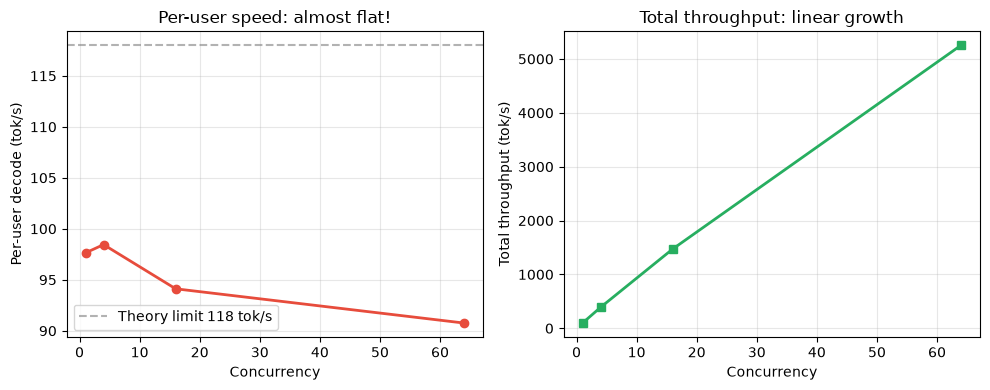

📈 并发 ×64：总吞吐 ×54，单用户速度仅降 7%
💰 翻译成人话：同一张卡服务 64 个人，每人的推理成本降为 1/54


In [11]:
# 画图：两条曲线讲清整个商业模式
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.sans-serif"] = ["DejaVu Sans"]
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(data["并发"], data["单用户速度"], "o-", color="#e74c3c", lw=2)
plt.axhline(118, ls="--", color="gray", alpha=0.6, label="Theory limit 118 tok/s")
plt.xlabel("Concurrency"); plt.ylabel("Per-user decode (tok/s)")
plt.title("Per-user speed: almost flat!"); plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(data["并发"], data["系统总吞吐"], "s-", color="#27ae60", lw=2)
plt.xlabel("Concurrency"); plt.ylabel("Total throughput (tok/s)")
plt.title("Total throughput: linear growth"); plt.grid(alpha=0.3)

plt.tight_layout(); plt.savefig("/workspace/week02_result.png", dpi=120); plt.show()

speedup = data["系统总吞吐"][-1] / data["系统总吞吐"][0]
drop = (1 - data["单用户速度"][-1] / data["单用户速度"][0]) * 100
print(f"📈 并发 ×{levels[-1]}：总吞吐 ×{speedup:.0f}，单用户速度仅降 {drop:.0f}%")
print(f"💰 翻译成人话：同一张卡服务 {levels[-1]} 个人，每人的推理成本降为 1/{speedup:.0f}")

## 6. 结果解读模板

把你的实测数字填进这张表，和 Week 1 理论对照（以下为 2026-09-07 的实测参考值）：

| 预言 | 理论值 | 实测值 | 结论 |
|---|---|---|---|
| ① 单流 decode 上限 | 118 tok/s | 104 tok/s（88%） | ✅ 带宽瓶颈实锤 |
| ② 免费午餐 | 拐点前不降速 | 1→64 并发仅降 13% | ✅ 成立 |
| ③ KV Cache 容量 | ~25 万 token | 253,056 token | ✅ 误差 <2% |

**课后思考**：
1. 如果把模型换成 FP8 量化版（权重减半），单流上限会变成多少？（Week 6 实验）
2. 并发加到 256 会发生什么？观察 TTFT 和 `num_requests_waiting`（Week 5 实验）
3. 为什么 TTFT 在高并发时上涨比 decode 速度更明显？（提示：prefill 是算力瓶颈，算力不能共享）

## 7. 收尾：关闭服务

实验做完记得释放 GPU。共享镜像给别人时，也应先执行下面的清理。

In [12]:
# 关闭 vLLM 服务，释放显存
server.terminate()
try:
    server.wait(timeout=30)
except subprocess.TimeoutExpired:
    server.kill()
print("服务已关闭")
!nvidia-smi --query-gpu=memory.used,memory.total --format=csv

服务已关闭


memory.used [MiB], memory.total [MiB]
2 MiB, 32607 MiB


## 8. 复现清单（共享镜像时附带给读者）

```bash
# 一键命令行复现（不用 Notebook 的版本）
pip install ninja
vllm serve /model/ModelScope/Qwen/Qwen2.5-7B-Instruct \
  --served-model-name Qwen2.5-7B-Instruct \
  --max-model-len 8192 --gpu-memory-utilization 0.90 --port 8000
```

**环境指纹**：vLLM 0.25.1 · torch 2.11.0+cu130 · CUDA 13.0 · RTX 5090 (sm_120) · 驱动 610.57

**下一站 Week 3**：给这个服务装上 Prometheus + Grafana 监控，让 TTFT/ITL/队列深度变成实时曲线。